**Citi Bike Trip Duration Project**

*In this notebook, we explore Citi Bike trips from May 2025 and train a few regression models to predict trip duration in minutes.*


# Project Overview

The goal is to predict `trip_duration_minutes` using information that is available when the ride starts.

This is a good regression problem for this dataset because the target is clear, easy to interpret, and connected to real usage patterns in the Citi Bike system.


# The Dataset

We use the official Citi Bike trip history data for May 2025.

The five monthly files were combined into one CSV:

- `202505-citibike-tripdata.csv`
- about 805 MB
- 4,325,553 trip rows

The main variables are timestamps, station names and IDs, coordinates, bike type, and rider type.


In [1]:
# Python ≥3.8 is required
import sys
assert sys.version_info >= (3, 8)

# Scikit-Learn ≥1.3 is required
import sklearn
assert sklearn.__version__ >= "1.3"

# Common imports
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# to make this notebook's output stable across runs
np.random.seed(42)

pd.set_option("display.max_columns", 50)
mpl.rc("axes", labelsize=14)
mpl.rc("xtick", labelsize=12)
mpl.rc("ytick", labelsize=12)
plt.rcParams["figure.figsize"] = (9, 5)

PROJECT_ROOT_DIR = "."
CHAPTER_ID = "citi_bike_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)


def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)


CSV_PATH = Path("202505-citibike-tripdata.csv")

CSV_PATH


PosixPath('202505-citibike-tripdata.csv')

In [2]:
file_size_mb = CSV_PATH.stat().st_size / (1024 ** 2)
print(f'CSV path: {CSV_PATH}')
print(f'File size: {file_size_mb:,.1f} MB')

CSV path: 202505-citibike-tripdata.csv
File size: 805.3 MB


# Load the Data


In [3]:
DATE_COLUMNS = ['started_at', 'ended_at']
RANDOM_STATE = 42

df_full = pd.read_csv(CSV_PATH, parse_dates=DATE_COLUMNS, low_memory=False)
df_clean = df_full.dropna().copy()

print(f'Full dataset shape: {df_full.shape}')
print(f'Clean dataset shape after dropna(): {df_clean.shape}')
print(f'Rows dropped because of missing values: {len(df_full) - len(df_clean):,}')
display(df_clean)

Full dataset shape: (4325553, 13)
Clean dataset shape after dropna(): (4311373, 13)
Rows dropped because of missing values: 14,180


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9DD48ABED65F7015,classic_bike,2025-05-04 14:19:21.329,2025-05-04 14:24:15.721,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
1,FF82206785FF6C44,classic_bike,2025-05-07 17:41:53.824,2025-05-07 17:50:02.742,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
2,5AEFCBE946C15D90,electric_bike,2025-05-11 20:21:07.908,2025-05-11 20:33:39.623,Coffey St & Ferris St,4137.14,3 St & 7 Ave,3905.15,40.678184,-74.017017,40.670384,-73.978397,member
3,6263552B7DC7E709,electric_bike,2025-05-08 14:06:13.781,2025-05-08 14:15:52.413,Coffey St & Ferris St,4137.14,Fulton St & Adams St,4637.06,40.678184,-74.017017,40.692418,-73.989495,member
4,D421E8FF99ED9C1B,electric_bike,2025-05-02 16:32:21.540,2025-05-02 16:39:50.612,North Moore St & Greenwich St,5470.12,Lafayette St & Grand St,5422.09,40.720195,-74.010301,40.720280,-73.998790,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325548,C73981593AE04116,classic_bike,2025-05-31 17:42:13.433,2025-05-31 17:56:27.359,W 26 St & 10 Ave,6382.05,E 20 St & FDR Dr,5886.13,40.749718,-74.002950,40.733209,-73.975681,casual
4325549,01418563828B2B47,electric_bike,2025-05-31 18:56:38.228,2025-05-31 19:08:24.745,Carroll St & Washington Ave,3887.03,West Drive & Prospect Park West,3651.04,40.668674,-73.961815,40.661063,-73.979453,casual
4325550,62BF0E22262F3243,electric_bike,2025-05-24 20:57:51.835,2025-05-24 21:05:39.601,Turner Pl & Coney Island Ave,3157.08,West Drive & Prospect Park West,3651.04,40.645210,-73.970730,40.661063,-73.979453,casual
4325551,C0697C866DE507E3,electric_bike,2025-05-19 20:26:19.231,2025-05-19 20:29:29.794,51 St & Queens Blvd,6167.03,61 St & Woodside Ave,6191.06,40.742900,-73.913950,40.745010,-73.903600,casual


In [4]:
display(df_clean.head())
display(df_clean.dtypes)
display(df_clean.isna().sum().sort_values(ascending=False))

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9DD48ABED65F7015,classic_bike,2025-05-04 14:19:21.329,2025-05-04 14:24:15.721,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
1,FF82206785FF6C44,classic_bike,2025-05-07 17:41:53.824,2025-05-07 17:50:02.742,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
2,5AEFCBE946C15D90,electric_bike,2025-05-11 20:21:07.908,2025-05-11 20:33:39.623,Coffey St & Ferris St,4137.14,3 St & 7 Ave,3905.15,40.678184,-74.017017,40.670384,-73.978397,member
3,6263552B7DC7E709,electric_bike,2025-05-08 14:06:13.781,2025-05-08 14:15:52.413,Coffey St & Ferris St,4137.14,Fulton St & Adams St,4637.06,40.678184,-74.017017,40.692418,-73.989495,member
4,D421E8FF99ED9C1B,electric_bike,2025-05-02 16:32:21.540,2025-05-02 16:39:50.612,North Moore St & Greenwich St,5470.12,Lafayette St & Grand St,5422.09,40.720195,-74.010301,40.720280,-73.998790,member


ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id                 str
end_station_name                 str
end_station_id                   str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64

# Take a Quick Look at the Data


In [5]:
df_clean['trip_duration_seconds'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds()
df_clean['trip_duration_minutes'] = df_clean['trip_duration_seconds'] / 60

duration_checks = {
    'clean_rows': len(df_clean),
    'missing_duration': int(df_clean['trip_duration_minutes'].isna().sum()),
    'non_positive_duration': int((df_clean['trip_duration_minutes'] <= 0).sum()),
    'duration_min_minutes': df_clean['trip_duration_minutes'].min(),
    'duration_median_minutes': df_clean['trip_duration_minutes'].median(),
    'duration_mean_minutes': df_clean['trip_duration_minutes'].mean(),
    'duration_max_minutes': df_clean['trip_duration_minutes'].max(),
}
duration_checks

{'clean_rows': 4311373,
 'missing_duration': 0,
 'non_positive_duration': 0,
 'duration_min_minutes': np.float64(1.00055),
 'duration_median_minutes': np.float64(9.135633333333335),
 'duration_mean_minutes': np.float64(12.89164123111516),
 'duration_max_minutes': np.float64(1498.8088)}

In [6]:
duplicate_ride_ids = df_clean['ride_id'].duplicated().sum()

# Roughly NYC-area 
coord_mask = (
    df_clean['start_lat'].between(40.3, 41.1) &
    df_clean['end_lat'].between(40.3, 41.1) &
    df_clean['start_lng'].between(-74.5, -73.4) &
    df_clean['end_lng'].between(-74.5, -73.4)
)

quality_checks = pd.Series({
    'duplicate_ride_ids_in_clean_data': int(duplicate_ride_ids),
    'rows_with_missing_start_station_id': int(df_clean['start_station_id'].isna().sum()),
    'rows_with_missing_end_station_id': int(df_clean['end_station_id'].isna().sum()),
    'rows_with_missing_coordinates': int(df_clean[['start_lat', 'start_lng', 'end_lat', 'end_lng']].isna().any(axis=1).sum()),
    'rows_outside_broad_nyc_coordinate_check': int((~coord_mask).sum()),
})

display(quality_checks)

duplicate_ride_ids_in_clean_data           0
rows_with_missing_start_station_id         0
rows_with_missing_end_station_id           0
rows_with_missing_coordinates              0
rows_outside_broad_nyc_coordinate_check    0
dtype: int64

In [7]:
full_missing = df_full.isna().sum().rename('missing_count').reset_index().rename(columns={'index': 'column'})
full_missing['missing_percent'] = full_missing['missing_count'] / len(df_full) * 100

full_summary = {
    'full_rows_before_dropna': len(df_full),
    'clean_rows_after_dropna': len(df_clean),
    'rows_removed_by_dropna': len(df_full) - len(df_clean),
    'duplicate_ride_ids_in_full_data': int(df_full['ride_id'].duplicated().sum()),
    'duplicate_ride_ids_in_clean_data': int(df_clean['ride_id'].duplicated().sum()),
    'rider_type_counts_clean_data': df_clean['member_casual'].value_counts(dropna=False).to_dict(),
    'bike_counts_clean_data': df_clean['rideable_type'].value_counts(dropna=False).to_dict(),
    'non_positive_duration_clean_data': int((df_clean['trip_duration_minutes'] <= 0).sum()),
}

display(full_summary)
display(full_missing.sort_values('missing_percent', ascending=False))

{'full_rows_before_dropna': 4325553,
 'clean_rows_after_dropna': 4311373,
 'rows_removed_by_dropna': 14180,
 'duplicate_ride_ids_in_full_data': 0,
 'duplicate_ride_ids_in_clean_data': 0,
 'rider_type_counts_clean_data': {'member': 3475064, 'casual': 836309},
 'bike_counts_clean_data': {'electric_bike': 2995108, 'classic_bike': 1316265},
 'non_positive_duration_clean_data': 0}

,column,missing_count,missing_percent
7,end_station_id,12726,0.294205
10,end_lat,12706,0.293743
11,end_lng,12706,0.293743
6,end_station_name,12343,0.285351
4,start_station_name,1691,0.039093
5,start_station_id,1691,0.039093
8,start_lat,1691,0.039093
9,start_lng,1691,0.039093
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


# Prepare the Data for Machine Learning Algorithms

The main preprocessing steps are simple:

- drop incomplete rows
- compute the target from the timestamps
- create time features
- compute straight-line distance
- one-hot encode bike type and rider type
- scale numeric features for linear regression
- cap the top 1% longest rides for the first model


We leave station names and station IDs.


In [8]:
def haversine_miles(lat1, lon1, lat2, lon2):
    radius_miles = 3958.8
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return radius_miles * c

def add_model_features(df):
    out = df.copy()
    out['trip_duration_minutes'] = (out['ended_at'] - out['started_at']).dt.total_seconds() / 60
    out['start_hour'] = out['started_at'].dt.hour
    out['start_dayofweek'] = out['started_at'].dt.dayofweek
    out['is_weekend'] = out['start_dayofweek'].isin([5, 6]).astype(int)
    out['start_month'] = out['started_at'].dt.month
    out['hour_sin'] = np.sin(2 * np.pi * out['start_hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['start_hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['start_dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['start_dayofweek'] / 7)
    out['route_distance_miles'] = haversine_miles(out['start_lat'], out['start_lng'], out['end_lat'], out['end_lng'])
    return out

df_features = add_model_features(df_clean)
display(df_features[['trip_duration_minutes', 'start_hour', 'start_dayofweek', 'is_weekend', 'route_distance_miles']].describe())

,trip_duration_minutes,start_hour,start_dayofweek,is_weekend,route_distance_miles
count,4.311373e+06,4.311373e+06,4.311373e+06,4.311373e+06,4.311373e+06
mean,1.289164e+01,1.411752e+01,3.160376e+00,3.077289e-01,1.281105e+00
std,1.859840e+01,5.084945e+00,1.927434e+00,4.615538e-01,1.092738e+00
min,1.000550e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.284950e+00,1.000000e+01,1.000000e+00,0.000000e+00,5.441514e-01
50%,9.135633e+00,1.500000e+01,3.000000e+00,0.000000e+00,9.599290e-01
75%,1.586418e+01,1.800000e+01,5.000000e+00,1.000000e+00,1.678548e+00
max,1.498809e+03,2.300000e+01,6.000000e+00,1.000000e+00,1.759840e+01


# Explore the Data




,trip_duration_minutes
count,4311373.00
mean,12.89
std,18.60
min,1.00
25%,5.28
50%,9.14
75%,15.86
90%,25.68
95%,33.79
99%,59.15


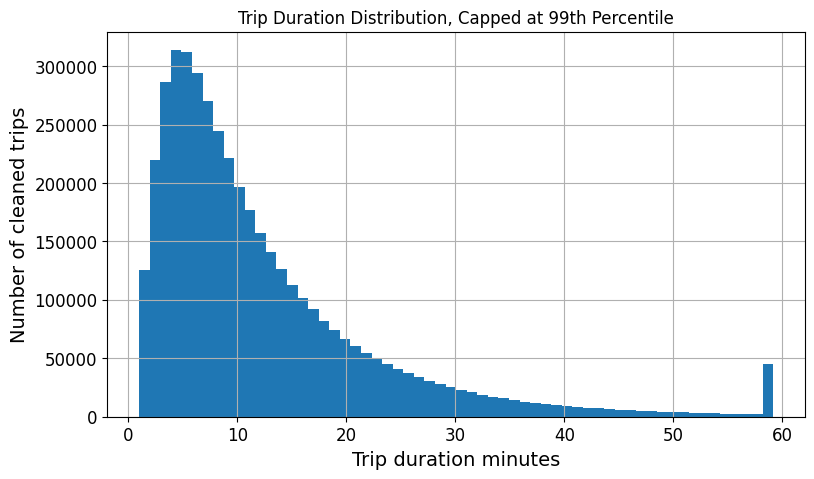

In [ ]:
plot_df = df_features.dropna(subset=['trip_duration_minutes']).copy()

duration_summary = (
    plot_df['trip_duration_minutes']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .rename('trip_duration_minutes')
    .to_frame()
)
display(duration_summary.round(2))

duration_cap = plot_df['trip_duration_minutes'].quantile(0.99)
plot_df['duration_minutes_capped_99'] = plot_df['trip_duration_minutes'].clip(upper=duration_cap)

ax = plot_df['duration_minutes_capped_99'].hist(bins=60)
ax.set_title('Trip Duration Distribution, Capped at 99th Percentile')
ax.set_xlabel('Trip duration minutes')
ax.set_ylabel('Number of trips')
plt.show()


,trip_count,median_duration,mean_duration
start_hour,,,
0,61897,9.03,12.76
1,36211,8.85,12.71
2,22902,8.76,12.66
3,15208,8.40,12.63
4,14060,7.63,11.69
5,29852,6.38,9.27
6,83603,6.81,9.47
7,174480,7.54,10.23
8,257469,8.13,10.87


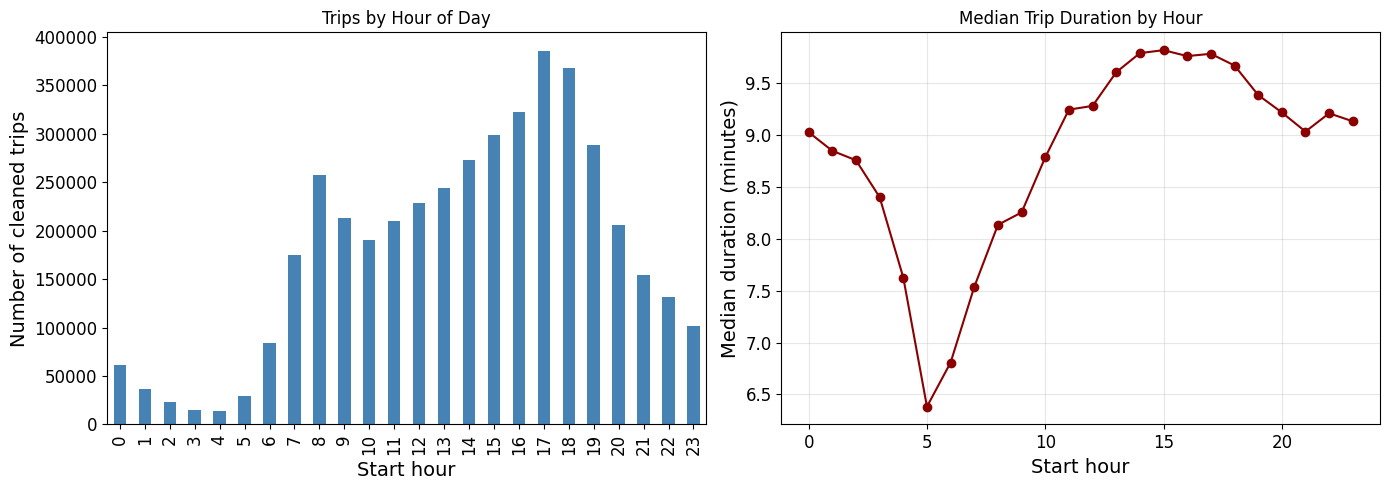

In [ ]:
hour_summary = (
    df_features.groupby('start_hour')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
display(hour_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_summary['trip_count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Trips by Hour of Day')
axes[0].set_xlabel('Start hour')
axes[0].set_ylabel('Number of trips')

hour_summary['median_duration'].plot(ax=axes[1], marker='o', color='darkred')
axes[1].set_title('Median Trip Duration by Hour')
axes[1].set_xlabel('Start hour')
axes[1].set_ylabel('Median duration (minutes)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Trip volume peaks in the late afternoon, especially around 5 to 6 pm, which looks like a strong commute pattern. But the busiest hours are not the longest trips: median duration is shortest in the early morning commute window and rises toward late morning and afternoon. That tells us start time matters, but not only because it changes traffic volume.


,trip_count,median_duration,mean_duration
Mon,527988,8.99,12.96
Tue,577739,8.53,11.73
Wed,451695,8.09,11.15
Thu,717373,8.71,11.94
Fri,709844,8.81,12.22
Sat,807469,10.59,14.88
Sun,519265,10.19,14.77


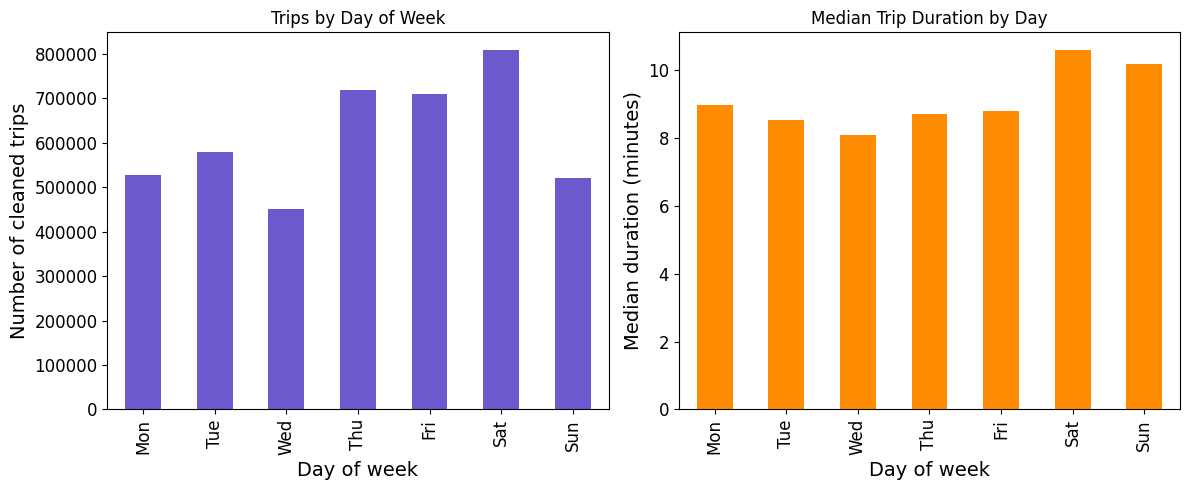

In [11]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_summary = (
    df_features.groupby('start_dayofweek')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
day_summary.index = [day_names[i] for i in day_summary.index]
display(day_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

day_summary['trip_count'].plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title('Trips by Day of Week')
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Number of cleaned trips')

day_summary['median_duration'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Median Trip Duration by Day')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Median duration (minutes)')

plt.tight_layout()
plt.show()


Saturday is the busiest day in the cleaned data, and weekend rides are also longer. The median trip is about 10.59 minutes on Saturday and 10.19 on Sunday, compared with roughly 8 to 9 minutes on weekdays. That suggests the system is capturing both commuting and more leisure-style riding, so weekend indicators should help the model.


,trip_count,median_duration,mean_duration
member_casual,,,
casual,836309,13.43,19.48
member,3475064,8.35,11.31


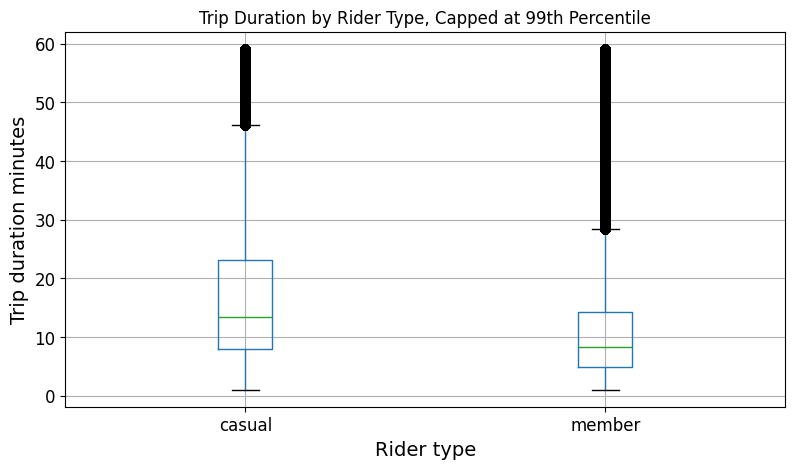

In [12]:
member_duration_summary = (
    plot_df.groupby('member_casual')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
display(member_duration_summary.round(2))

ax = plot_df.boxplot(column='duration_minutes_capped_99', by='member_casual')
ax.set_title('Trip Duration by Rider Type, Capped at 99th Percentile')
ax.set_xlabel('Rider type')
ax.set_ylabel('Trip duration minutes')
plt.suptitle('')
plt.show()


Rider type matters a lot. Casual riders have a median trip duration of about 13.43 minutes, while members are closer to 8.35 minutes. 

,trip_count,median_duration,mean_duration
rideable_type,,,
classic_bike,1316265,8.65,13.27
electric_bike,2995108,9.33,12.72


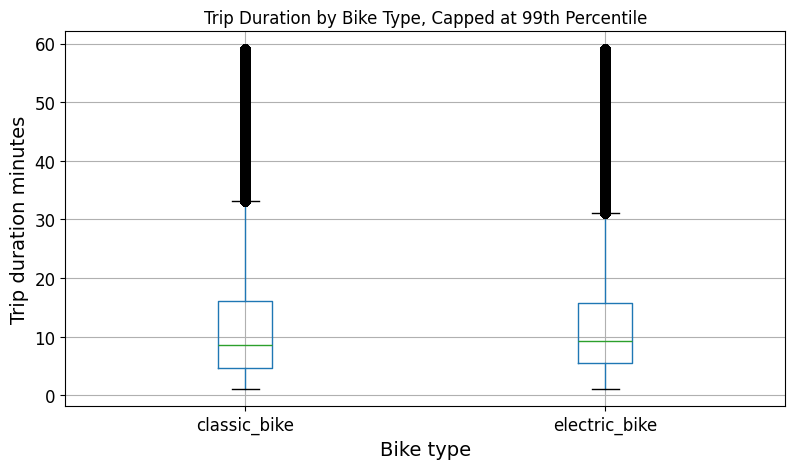

In [13]:
bike_duration_summary = (
    plot_df.groupby('rideable_type')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
display(bike_duration_summary.round(2))

ax = plot_df.boxplot(column='duration_minutes_capped_99', by='rideable_type')
ax.set_title('Trip Duration by Bike Type, Capped at 99th Percentile')
ax.set_xlabel('Bike type')
ax.set_ylabel('Trip duration minutes')
plt.suptitle('')
plt.show()


 Electric bikes have a slightly higher median duration than classic bikes, while classic bikes have a slightly higher mean because of a longer tail of very long rides.

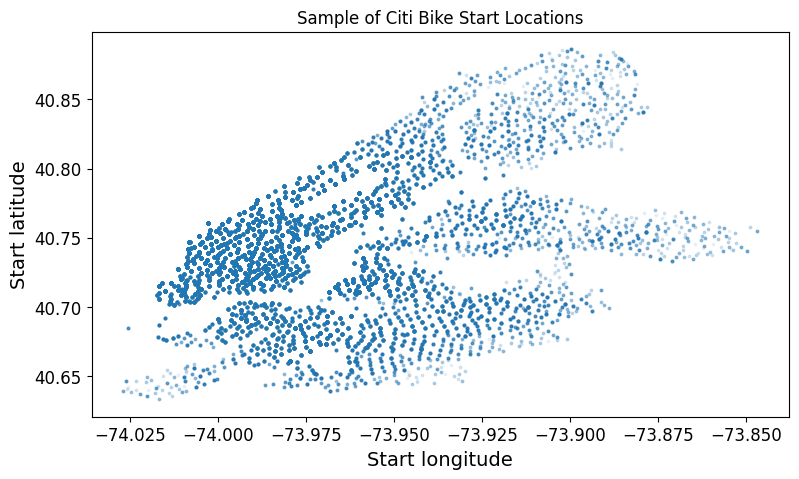

In [14]:
location_df = df_features.dropna(subset=['start_lat', 'start_lng'])
location_plot_df = location_df.sample(n=min(100_000, len(location_df)), random_state=RANDOM_STATE)

ax = location_plot_df.plot(
    kind='scatter',
    x='start_lng',
    y='start_lat',
    alpha=0.08,
    s=3,
)
ax.set_title('Sample of Citi Bike Start Locations')
ax.set_xlabel('Start longitude')
ax.set_ylabel('Start latitude')
plt.show()


# Traffic Hotspots and Bike Type Mix

Now let's look at where trips are concentrated and how electric-bike usage changes across busy areas.


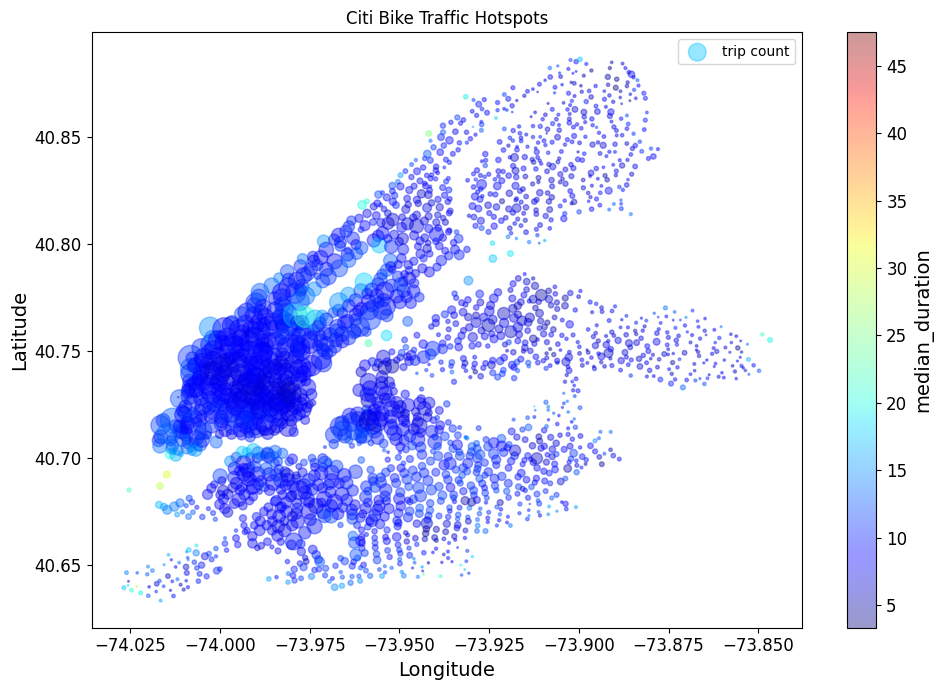

In [15]:
traffic_df = df_features.dropna(subset=['start_lat', 'start_lng', 'trip_duration_minutes']).copy()

station_traffic = (
    traffic_df.groupby(['start_lng', 'start_lat'])
    .agg(
        trip_count=('ride_id', 'size'),
        median_duration=('trip_duration_minutes', 'median'),
    )
    .reset_index()
)

station_traffic.plot(
    kind='scatter',
    x='start_lng',
    y='start_lat',
    alpha=0.4,
    s=station_traffic['trip_count'] / 45,
    label='trip count',
    figsize=(10, 7),
    c='median_duration',
    cmap=plt.get_cmap('jet'),
    colorbar=True,
    sharex=False,
)
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Citi Bike Traffic Hotspots')
save_fig('citi_bike_hotspot_map')
plt.show()


,share_percent
rideable_type,
electric_bike,69.47
classic_bike,30.53


rideable_type,classic_bike,electric_bike
member_casual,,
casual,27.05,72.95
member,31.37,68.63


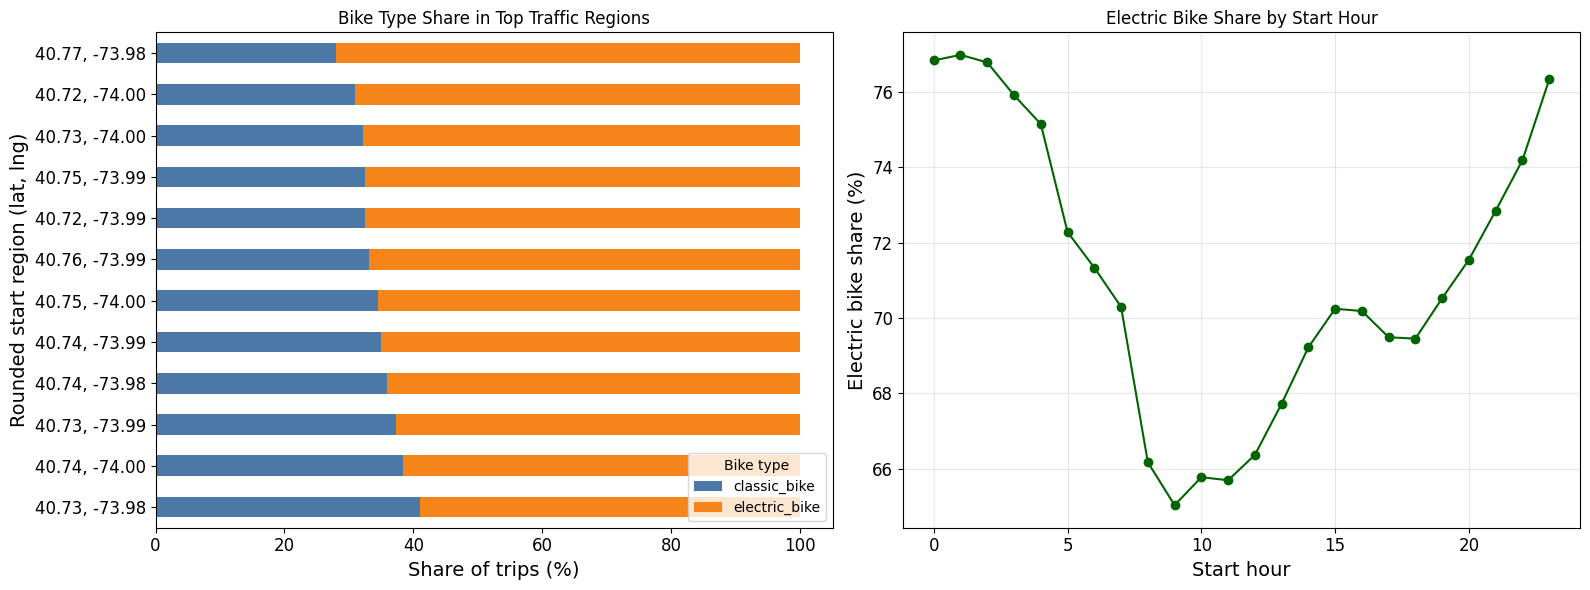

In [16]:
traffic_df = traffic_df.copy()
traffic_df['region_lat'] = traffic_df['start_lat'].round(2)
traffic_df['region_lng'] = traffic_df['start_lng'].round(2)
traffic_df['start_region'] = (
    traffic_df['region_lat'].map(lambda x: f'{x:.2f}') + ', ' +
    traffic_df['region_lng'].map(lambda x: f'{x:.2f}')
)

region_summary = (
    traffic_df.groupby('start_region')
    .agg(trip_count=('ride_id', 'size'))
    .sort_values('trip_count', ascending=False)
    .head(12)
)
top_region_labels = region_summary.index.tolist()

overall_bike_share = (
    traffic_df['rideable_type']
    .value_counts(normalize=True)
    .mul(100)
    .rename('share_percent')
    .to_frame()
)
display(overall_bike_share.round(2))

bike_by_rider = pd.crosstab(
    traffic_df['member_casual'],
    traffic_df['rideable_type'],
    normalize='index',
).mul(100)
display(bike_by_rider.round(2))

region_bike_share = (
    traffic_df[traffic_df['start_region'].isin(top_region_labels)]
    .groupby(['start_region', 'rideable_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(top_region_labels)
    .reindex(columns=['classic_bike', 'electric_bike'], fill_value=0)
)
region_bike_share = region_bike_share.div(region_bike_share.sum(axis=1), axis=0).mul(100)

hour_bike_share = (
    traffic_df.groupby('start_hour')
    .agg(electric_share=('rideable_type', lambda s: s.eq('electric_bike').mean() * 100))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_bike_share.sort_values('electric_bike').plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=['#4c78a8', '#f58518'],
)
axes[0].set_title('Bike Type Share in Top Traffic Regions')
axes[0].set_xlabel('Share of trips (%)')
axes[0].set_ylabel('Rounded start region (lat, lng)')
axes[0].legend(title='Bike type', loc='lower right')

hour_bike_share['electric_share'].plot(ax=axes[1], marker='o', color='darkgreen')
axes[1].set_title('Electric Bike Share by Start Hour')
axes[1].set_xlabel('Start hour')
axes[1].set_ylabel('Electric bike share (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Training Models

In [ ]:
model_attribs = [
    'rideable_type',
    'member_casual',
    'start_hour',
    'start_dayofweek',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'start_lat',
    'start_lng',
    'end_lat',
    'end_lng',
    'route_distance_miles',
]


trip_data = df_features[model_attribs + ['started_at', 'trip_duration_minutes']].dropna().copy()
trip_data = trip_data[trip_data['trip_duration_minutes'] > 0].copy()
trip_duration_cap = trip_data['trip_duration_minutes'].quantile(0.99)
trip_data = trip_data[trip_data['trip_duration_minutes'] <= trip_duration_cap].copy()
trip_data = trip_data.sort_values('started_at').reset_index(drop=True)

# keep the split chronological by disabling shuffling
trip_train_valid_set, trip_test_set = train_test_split(
    trip_data,
    test_size=0.15,
    shuffle=False,
)
trip_train_set, trip_valid_set = train_test_split(
    trip_train_valid_set,
    test_size= 0.15 / 0.85,
    shuffle=False,
)

trip_train = trip_train_set.drop(['started_at', 'trip_duration_minutes'], axis=1)
trip_valid = trip_valid_set.drop(['started_at', 'trip_duration_minutes'], axis=1)
trip_test = trip_test_set.drop(['started_at', 'trip_duration_minutes'], axis=1)

trip_train_labels = trip_train_set['trip_duration_minutes'].copy()
trip_valid_labels = trip_valid_set['trip_duration_minutes'].copy()
trip_test_labels = trip_test_set['trip_duration_minutes'].copy()

model_summary = pd.DataFrame({
    'rows': [len(trip_train_set), len(trip_valid_set), len(trip_test_set)],
    'start_date': [
        trip_train_set['started_at'].min(),
        trip_valid_set['started_at'].min(),
        trip_test_set['started_at'].min(),
    ],
    'end_date': [
        trip_train_set['started_at'].max(),
        trip_valid_set['started_at'].max(),
        trip_test_set['started_at'].max(),
    ],
}, index=['train', 'validation', 'test'])
model_summary.loc['duration_cap_minutes', 'rows'] = round(trip_duration_cap, 2)
display(model_summary)


,rows,start_date,end_date
train,2987781.00,2025-04-30 23:07:09.714,2025-05-21 23:34:42.958
validation,640239.00,2025-05-21 23:34:43.008,2025-05-27 16:04:48.979
test,640239.00,2025-05-27 16:04:49.458,2025-05-31 23:58:06.793
duration_cap_minutes,59.15,NaT,NaT


In [18]:
num_attribs = [
    'start_hour',
    'start_dayofweek',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'start_lat',
    'start_lng',
    'end_lat',
    'end_lng',
    'route_distance_miles',
]
cat_attribs = ['rideable_type', 'member_casual']


def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs),
])

trip_train_prepared = full_pipeline.fit_transform(trip_train)
trip_valid_prepared = full_pipeline.transform(trip_valid)
trip_test_prepared = full_pipeline.transform(trip_test)

lin_reg = LinearRegression()
lin_reg.fit(trip_train_prepared, trip_train_labels)

lin_valid_pred = lin_reg.predict(trip_valid_prepared)
lin_test_pred = lin_reg.predict(trip_test_prepared)

lin_valid_mae, lin_valid_rmse, lin_valid_r2 = evaluate_regression(trip_valid_labels, lin_valid_pred)
lin_test_mae, lin_test_rmse, lin_test_r2 = evaluate_regression(trip_test_labels, lin_test_pred)

lin_scores = pd.DataFrame([
    {
        'model': 'linear_regression',
        'valid_mae': lin_valid_mae,
        'valid_rmse': lin_valid_rmse,
        'valid_r2': lin_valid_r2,
        'test_mae': lin_test_mae,
        'test_rmse': lin_test_rmse,
        'test_r2': lin_test_r2,
    }
])
display(lin_scores.round(3))


,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
0,linear_regression,4.159,6.981,0.512,3.641,6.017,0.558


In [19]:
# we use a sample of the training and validation sets to keep tuning managable
sample_train = trip_train.sample(n=min(120_000, len(trip_train)), random_state=42)
sample_train_labels = trip_train_labels.loc[sample_train.index]
sample_valid = trip_valid.sample(n=min(40_000, len(trip_valid)), random_state=42)
sample_valid_labels = trip_valid_labels.loc[sample_valid.index]

forest_pipeline = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_attribs),
], sparse_threshold=0)

sample_train_prepared = forest_pipeline.fit_transform(sample_train)
sample_valid_prepared = forest_pipeline.transform(sample_valid)

param_grid = [
    {'n_estimators': 120, 'max_depth': 12, 'min_samples_leaf': 5},
    {'n_estimators': 160, 'max_depth': 16, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 3},
]

forest_scores = []
best_forest_params = None
best_forest_mae = float('inf')

for params in param_grid:
    forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    forest_reg.fit(sample_train_prepared, sample_train_labels)
    sample_valid_pred = forest_reg.predict(sample_valid_prepared)
    valid_mae, valid_rmse, valid_r2 = evaluate_regression(sample_valid_labels, sample_valid_pred)

    forest_scores.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'min_samples_leaf': params['min_samples_leaf'],
        'valid_mae': valid_mae,
        'valid_rmse': valid_rmse,
        'valid_r2': valid_r2,
    })

    if valid_mae < best_forest_mae:
        best_forest_mae = valid_mae
        best_forest_params = params

forest_scores = pd.DataFrame(forest_scores).sort_values('valid_mae').reset_index(drop=True)
display(forest_scores.round(3))
print('Best random forest parameters:', best_forest_params)


,n_estimators,max_depth,min_samples_leaf,valid_mae,valid_rmse,valid_r2
0,120,12,5,3.748,6.397,0.590
1,160,16,5,3.756,6.390,0.591
2,200,20,3,3.790,6.412,0.588


Best random forest parameters: {'n_estimators': 120, 'max_depth': 12, 'min_samples_leaf': 5}


,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
1,random_forest,3.734,6.375,0.593,3.278,5.554,0.623
0,linear_regression,4.159,6.981,0.512,3.641,6.017,0.558


,feature,importance
11,route_distance_miles,0.801
9,end_lat,0.022
7,start_lat,0.022
13,rideable_type_electric_bike,0.022
10,end_lng,0.021
8,start_lng,0.021
14,member_casual_casual,0.019
12,rideable_type_classic_bike,0.018
15,member_casual_member,0.015
0,start_hour,0.010


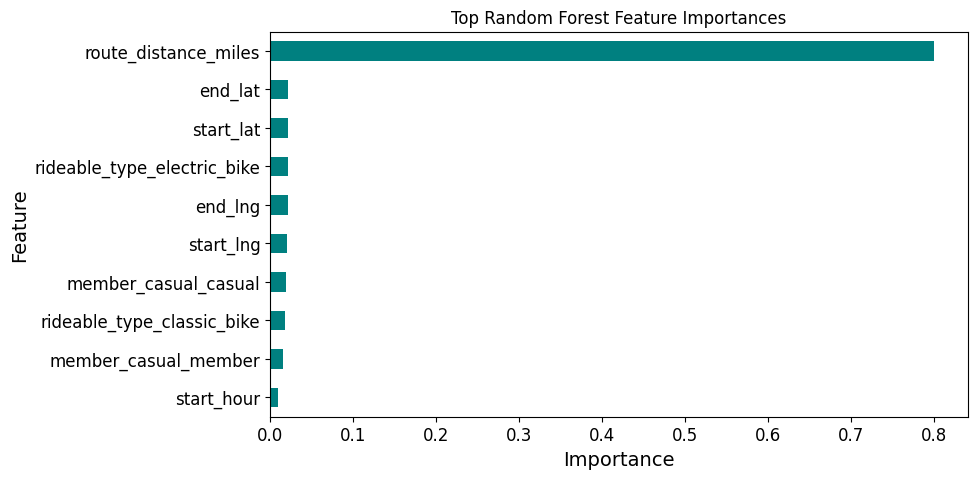

In [20]:
# train the model using the best hyperparams
forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1, **best_forest_params)
forest_reg.fit(sample_train_prepared, sample_train_labels)

trip_valid_prepared_for_forest = forest_pipeline.transform(trip_valid)
trip_test_prepared_for_forest = forest_pipeline.transform(trip_test)

rf_valid_pred = forest_reg.predict(trip_valid_prepared_for_forest)
rf_test_pred = forest_reg.predict(trip_test_prepared_for_forest)

rf_valid_mae, rf_valid_rmse, rf_valid_r2 = evaluate_regression(trip_valid_labels, rf_valid_pred)
rf_test_mae, rf_test_rmse, rf_test_r2 = evaluate_regression(trip_test_labels, rf_test_pred)

forest_scores = pd.DataFrame([
    {
        'model': 'random_forest',
        'valid_mae': rf_valid_mae,
        'valid_rmse': rf_valid_rmse,
        'valid_r2': rf_valid_r2,
        'test_mae': rf_test_mae,
        'test_rmse': rf_test_rmse,
        'test_r2': rf_test_r2,
    }
])

all_model_scores = pd.concat([lin_scores, forest_scores], ignore_index=True).sort_values('test_mae')
display(all_model_scores.round(3))

cat_encoder = forest_pipeline.named_transformers_['cat']
extra_attribs = list(cat_encoder.get_feature_names_out(cat_attribs))
attributes = num_attribs + extra_attribs
feature_importances = pd.DataFrame({
    'feature': attributes,
    'importance': forest_reg.feature_importances_,
}).sort_values('importance', ascending=False)
display(feature_importances.head(10).round(3))

ax = feature_importances.head(10).sort_values('importance').plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False,
    color='teal',
)
ax.set_title('Top Random Forest Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.show()


# Evaluate the Model


Residual quantiles:


0.01   -10.569
0.10    -4.394
0.25    -2.530
0.50    -1.083
0.75     0.795
0.90     4.333
0.99    24.158
Name: residual, dtype: float64

,mean,median,count
member_casual,,,
casual,5.414,3.663,113235
member,2.819,1.821,527004


,mean,median,count
rideable_type,,,
classic_bike,3.451,2.030,181050
electric_bike,3.210,2.016,459189


,mean,median,count
duration_bin,,,
"(-0.001, 5.0]",2.154,1.677,148638
"(5.0, 10.0]",2.002,1.560,209810
"(10.0, 20.0]",3.112,2.465,188384
"(20.0, 40.0]",6.565,4.671,82245
"(40.0, 60.0]",20.811,19.516,11162


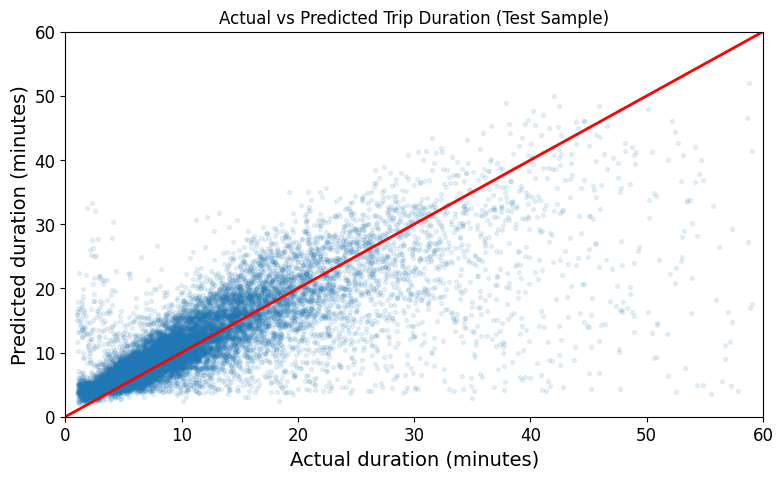

In [21]:
test_eval = trip_test.copy()
test_eval['actual_duration'] = trip_test_labels.values
test_eval['predicted_duration'] = rf_test_pred
test_eval['abs_error'] = (test_eval['actual_duration'] - test_eval['predicted_duration']).abs()
test_eval['residual'] = test_eval['actual_duration'] - test_eval['predicted_duration']
test_eval['duration_bin'] = pd.cut(
    test_eval['actual_duration'],
    bins=[0, 5, 10, 20, 40, 60],
    include_lowest=True,
)

error_by_rider = test_eval.groupby('member_casual')['abs_error'].agg(['mean', 'median', 'count'])
error_by_bike = test_eval.groupby('rideable_type')['abs_error'].agg(['mean', 'median', 'count'])
error_by_duration = test_eval.groupby('duration_bin', observed=False)['abs_error'].agg(['mean', 'median', 'count'])

print('Residual quantiles:')
display(test_eval['residual'].quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(3))
display(error_by_rider.round(3))
display(error_by_bike.round(3))
display(error_by_duration.round(3))

scatter_sample = test_eval.sample(n=min(15_000, len(test_eval)), random_state=42)
ax = scatter_sample.plot(
    kind='scatter',
    x='actual_duration',
    y='predicted_duration',
    alpha=0.10,
    s=8,
)
ax.plot([0, 60], [0, 60], 'r-', linewidth=2)
ax.set_title('Actual vs Predicted Trip Duration (Test Sample)')
ax.set_xlabel('Actual duration (minutes)')
ax.set_ylabel('Predicted duration (minutes)')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.show()


## References


- Citi Bike. "System Data." https://citibikenyc.com/system-data
- Jiang, W. (2022). "Bike sharing usage prediction with deep learning: a survey." *Neural Computing and Applications*. https://pmc.ncbi.nlm.nih.gov/articles/PMC9185130/
- Yang, H., Xie, K., Ozbay, K., Ma, Y., & Wang, Z. (2018). "Use of Deep Learning to Predict Daily Usage of Bike Sharing Systems." *Transportation Research Record*. https://journals.sagepub.com/doi/10.1177/0361198118801354
- "Predicting Trip Duration and Distance in Bike-Sharing Systems Using Dynamic Time Warping." *Applied Artificial Intelligence* / Taylor & Francis. https://www.tandfonline.com/doi/full/10.1080/08839514.2025.2474786?af=R
